In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

Rows: 1470
Columns: 35
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  14

Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

In [5]:
df["Attrition_Flag"] = df["Attrition"].map({
    "Yes":1,
    "No":0})
df[["Attrition","Attrition_Flag"]].head()

,Attrition,Attrition_Flag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [6]:
total_employees = len(df)
total_attrition = df["Attrition_Flag"].sum()
attrition_rate = (
    total_attrition /
    total_employees)*100
print(f"Total Employees: {total_employees}")
print(f"Total Attrition: {total_attrition}")
print(f"Attrition Rate: {attrition_rate:.2f}%")

Total Employees: 1470
Total Attrition: 237
Attrition Rate: 16.12%


In [7]:
kpi_summary = pd.DataFrame({
    "Metric":[
        "Employee Count",
        "Average Monthly Income",
        "Average Years At Company",
        "Average Job Satisfaction",
        "Attrition Rate"],
    "Stayed":[
        len(df[df["Attrition_Flag"]==0]),
        round(df[df["Attrition_Flag"]==0]["MonthlyIncome"].mean(),2),
        round(df[df["Attrition_Flag"]==0]["YearsAtCompany"].mean(),2),
        round(df[df["Attrition_Flag"]==0]["JobSatisfaction"].mean(),2),
        "0%"],
    "Left":[
        len(df[df["Attrition_Flag"]==1]),
        round(df[df["Attrition_Flag"]==1]["MonthlyIncome"].mean(),2),
        round(df[df["Attrition_Flag"]==1]["YearsAtCompany"].mean(),2),
        round(df[df["Attrition_Flag"]==1]["JobSatisfaction"].mean(),2),
        "100%"]})
kpi_summary

,Metric,Stayed,Left
0,Employee Count,1233,237
1,Average Monthly Income,6832.74,4787.09
2,Average Years At Company,7.37,5.13
3,Average Job Satisfaction,2.78,2.47
4,Attrition Rate,0%,100%


In [8]:
department_attrition = (
    df.groupby("Department")
    ["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
    *100)
department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition_Flag, dtype: float64

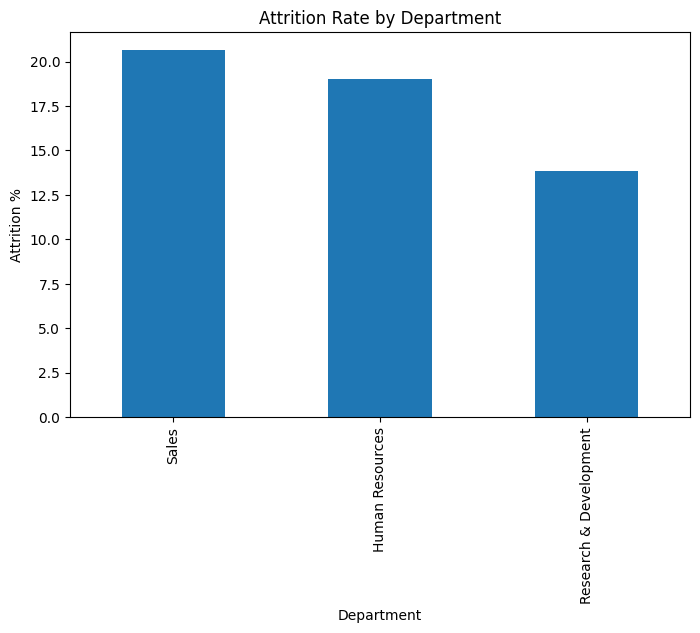

In [9]:
plt.figure(figsize=(8,5))
department_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition %")
plt.xlabel("Department")
plt.show()

In [10]:
jobrole_attrition = (
    df.groupby("JobRole")
    ["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
    *100)
jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition_Flag, dtype: float64

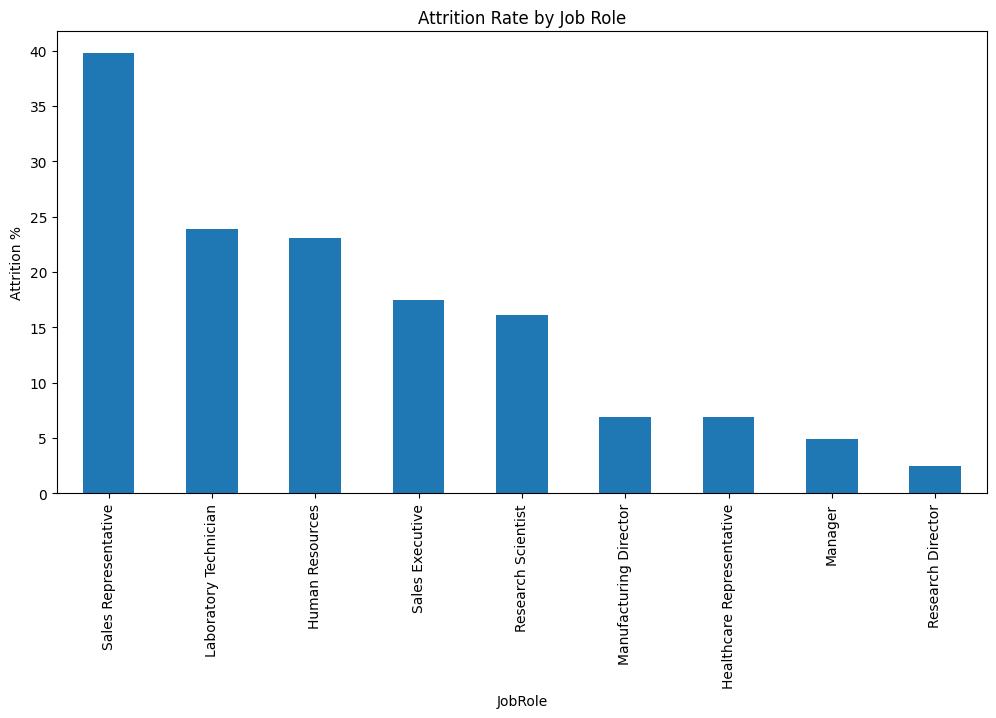

In [11]:
plt.figure(figsize=(12,6))
jobrole_attrition.plot(kind="bar")
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition %")
plt.show()

In [12]:
overtime_attrition = (
    df.groupby("OverTime")
    ["Attrition_Flag"]
    .mean()
    *100)
overtime_attrition

OverTime
No     10.436433
Yes    30.528846
Name: Attrition_Flag, dtype: float64

In [13]:
marital_attrition = (
    df.groupby("MaritalStatus")
    ["Attrition_Flag"]
    .mean()
    *100)
marital_attrition

MaritalStatus
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: Attrition_Flag, dtype: float64

In [14]:
gender_attrition = (
    df.groupby("Gender")
    ["Attrition_Flag"]
    .mean()
    *100)
gender_attrition

Gender
Female    14.795918
Male      17.006803
Name: Attrition_Flag, dtype: float64

In [15]:
df["Tenure_Group"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1,2,5,10,100],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "11+ Years"])

In [16]:
tenure_attrition = (
    df.groupby("Tenure_Group")
    ["Attrition_Flag"]
    .mean()
    *100)
tenure_attrition

Tenure_Group
0-2 Years     29.824561
3-5 Years     13.824885
6-10 Years    12.276786
11+ Years      8.130081
Name: Attrition_Flag, dtype: float64

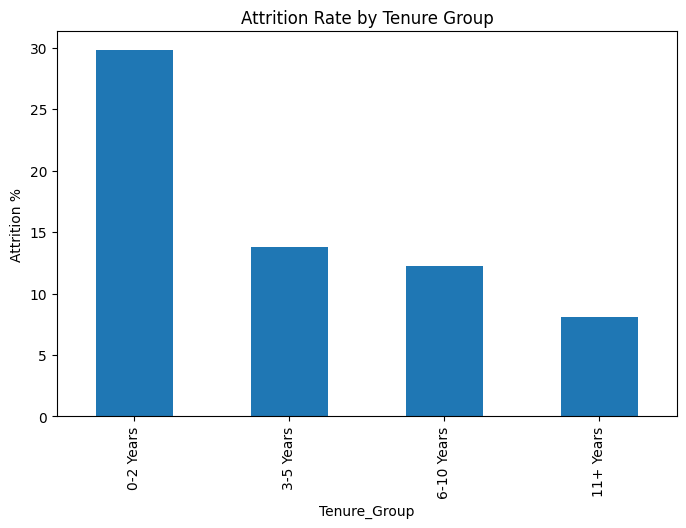

In [17]:
plt.figure(figsize=(8,5))
tenure_attrition.plot(kind="bar")
plt.title("Attrition Rate by Tenure Group")
plt.ylabel("Attrition %")
plt.show()

In [18]:
df["Income_Quartile"] = pd.qcut(
    df["MonthlyIncome"],
    q=4,
    labels=[
        "Q1 Lowest",
        "Q2",
        "Q3",
        "Q4 Highest"])

In [19]:
income_attrition = (
    df.groupby("Income_Quartile")
    ["Attrition_Flag"]
    .mean()
    *100)
income_attrition

Income_Quartile
Q1 Lowest     29.268293
Q2            14.207650
Q3            10.626703
Q4 Highest    10.326087
Name: Attrition_Flag, dtype: float64

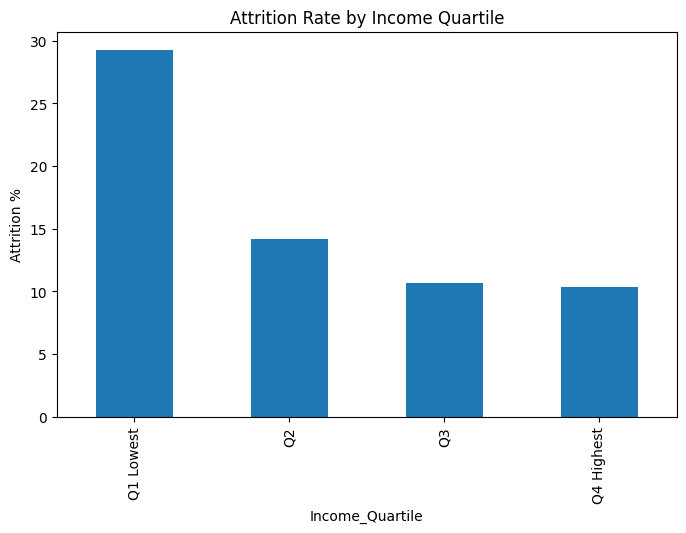

In [20]:
plt.figure(figsize=(8,5))
income_attrition.plot(kind="bar")
plt.title("Attrition Rate by Income Quartile")
plt.ylabel("Attrition %")
plt.show()

In [21]:
dept_jobsat = pd.pivot_table(
    df,
    values="Attrition_Flag",
    index="Department",
    columns="JobSatisfaction",
    aggfunc="mean"
)*100
dept_jobsat

JobSatisfaction,1,2,3,4
Department,,,,
Human Resources,45.454545,10.000000,20.000000,11.764706
Research & Development,19.791667,13.793103,14.333333,9.491525
Sales,26.744186,23.255814,21.259843,14.965986


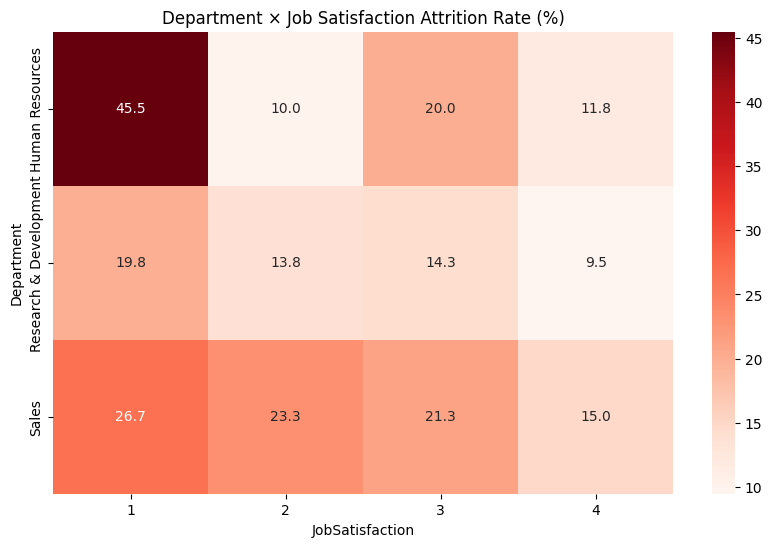

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(
    dept_jobsat,
    annot=True,
    fmt=".1f",
    cmap="Reds")
plt.title(
    "Department × Job Satisfaction Attrition Rate (%)")
plt.show()

In [23]:
dept_wlb = pd.pivot_table(
    df,
    values="Attrition_Flag",
    index="Department",
    columns="WorkLifeBalance",
    aggfunc="mean"
)*100
dept_wlb

WorkLifeBalance,1,2,3,4
Department,,,,
Human Resources,0.000000,28.571429,21.428571,10.000000
Research & Development,31.666667,13.617021,11.826087,15.384615
Sales,37.500000,23.529412,18.115942,23.076923


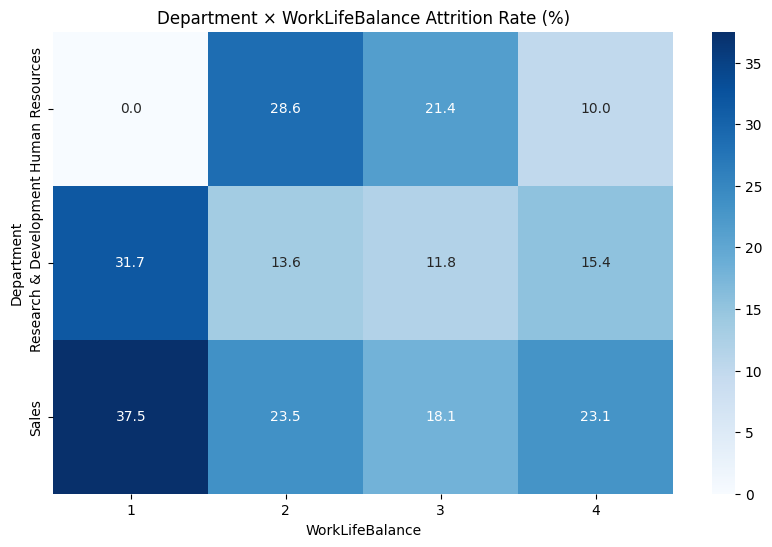

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(
    dept_wlb,
    annot=True,
    fmt=".1f",
    cmap="Blues")
plt.title(
    "Department × WorkLifeBalance Attrition Rate (%)")
plt.show()

In [25]:
numeric_df = df.select_dtypes(include=np.number)
corr = (
    numeric_df
    .corr()["Attrition_Flag"]
    .abs()
    .sort_values(ascending=False))
top10_corr = corr[1:11]
top10_corr

TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481
Name: Attrition_Flag, dtype: float64

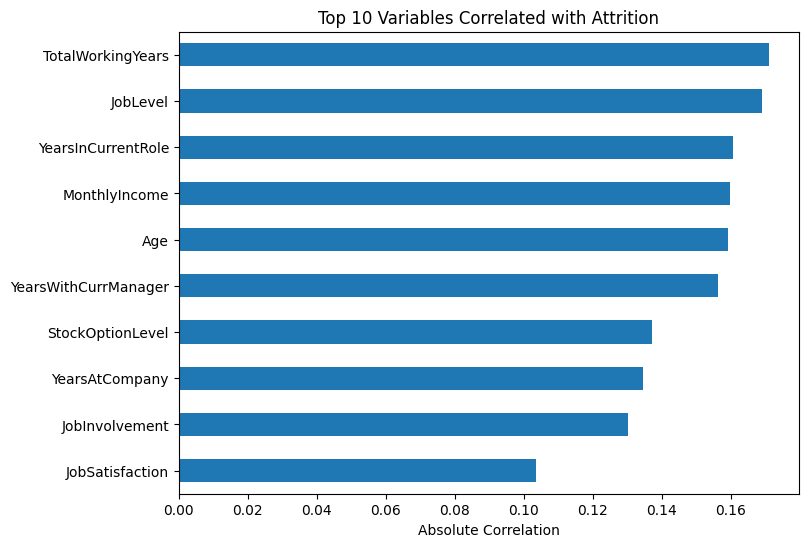

In [26]:
plt.figure(figsize=(8,6))
top10_corr.sort_values().plot(
    kind="barh")
plt.title(
    "Top 10 Variables Correlated with Attrition")
plt.xlabel("Absolute Correlation")
plt.show()

In [27]:
risk_profiles = (
    df.groupby([
        "OverTime",
        "JobSatisfaction",
        "WorkLifeBalance"
    ])
    ["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
    .head(10))
risk_profiles

OverTime  JobSatisfaction  WorkLifeBalance
Yes       2                1                  1.000000
          1                1                  1.000000
          2                4                  0.666667
No        1                1                  0.400000
Yes       3                1                  0.400000
No        3                1                  0.375000
Yes       2                2                  0.368421
          3                3                  0.364865
          4                1                  0.357143
          1                2                  0.352941
Name: Attrition_Flag, dtype: float64

In [ ]:
leavers = df[
    df["Attrition_Flag"]==1]
total_attrition_cost = (
    leavers["MonthlyIncome"].sum()
    *6)
print(
    f"Estimated Attrition Cost: ${total_attrition_cost:,.0f}"
) # bonus

Estimated Attrition Cost: $6,807,246


In [ ]:
risk_group = df[
    (df["OverTime"]=="Yes")
    &
    (df["JobSatisfaction"]==1)
    &
    (df["Income_Quartile"]=="Q1 Lowest")]
risk_rate = (
    risk_group["Attrition_Flag"]
    .mean()
    *100)
print(
    f"Risk Group Attrition Rate: {risk_rate:.2f}%")
print(
    f"Employees in Group: {len(risk_group)}") #bonus

Risk Group Attrition Rate: 65.22%
Employees in Group: 23
